# 분석 단계별 프로세스 - 순환 신경망 알고리즘

## 1. 라이브러리 / 데이터 불러오기

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

DATA_DIR = Path("../data")

df = pd.read_csv(DATA_DIR / "okm_augumented_2021.csv")

## 2. 데이터 종류 및 개수 확인

In [2]:
# 전체 데이터셋 출력
df

# 상위 기본 5개 데이터 확인
df.head()

# head 와 반대로 뒤에서부터 데이터 확인
df.tail()

# 데이터 전체 구조 및 타입 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


## 3. 데이터 정제(전처리)

#### 3-0. 데이터 품질 진단

모델링 전에 데이터 품질을 두 가지 지표로 확인한다.

- **완전성(Completeness)**: 전체 셀 중 결측치가 아닌 셀의 비율
- **유일성(Uniqueness)**: 전체 행 중 중복되지 않은(서로 다른) 행의 비율

In [3]:
total_cells = df.size
non_null_cells = df.notna().sum().sum()
completeness = non_null_cells / total_cells * 100

total_rows = len(df)
unique_rows = len(df.drop_duplicates())
uniqueness = unique_rows / total_rows * 100

print(f"완전성(Completeness): {completeness:.2f}%  (non-null {non_null_cells:,} / 전체 {total_cells:,} 셀)")
print(f"유일성(Uniqueness)  : {uniqueness:.2f}%  (unique {unique_rows:,} / 전체 {total_rows:,} 행)")

column_completeness = (df.notna().mean() * 100).round(2).sort_values().rename("completeness(%)")
column_completeness.to_frame()

완전성(Completeness): 99.98%  (non-null 111,003 / 전체 111,024 셀)
유일성(Uniqueness)  : 100.00%  (unique 6,168 / 전체 6,168 행)


,completeness(%)
공장인원,99.72
풍속,99.95
강수량,99.98
날짜,100.00
m,100.00
d,100.00
day,100.00
전기요금(계절),100.00
습도,100.00
기온,100.00


#### 3-1. 결측치 처리

In [4]:
# 결측치 개수 확인
df.isnull().sum()

# fillna()를 이용해 특정 변수 결측치 값 채우기
# df.fillna({'강수량': 0}, inplace = True)
df.fillna(0, inplace=True)

df_frame = df
df.isnull().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          0
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

In [5]:
# Random Forest용 데이터 별도 보관
df_frame = df.copy()

# 다른 notebook에서 사용하기 위해 저장
df_frame.to_csv(
    "../results/df_frame.csv",
    index=False
)

#### 3-2. 데이터 특성 파악

<Axes: >

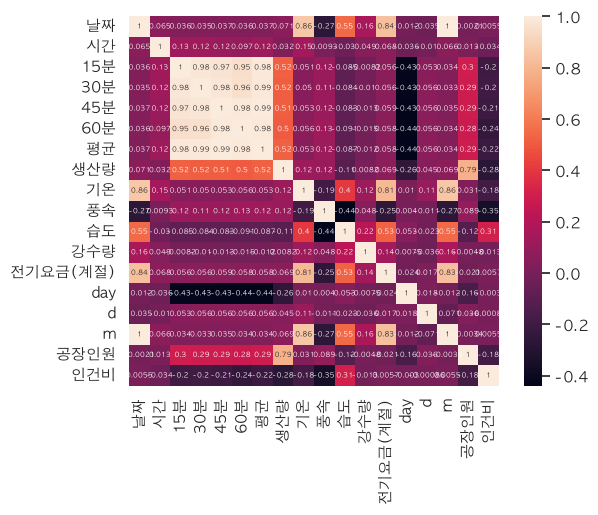

In [6]:
# 요약통계량 확인
df.describe()

# 각 데이터 간 상관관계 확인
df.corr()

plt.rc("font", family="AppleGothic")
sns.set(font="AppleGothic", rc={"axes.unicode_minus": False}, style="darkgrid")
sns.heatmap(df.corr(), vmax=1, square=True, annot=True, annot_kws={"size": 5})

#### 3-3. 데이터 정제

In [7]:
# 사용하지 않는 컬럼 제거
df = df.drop(columns=['생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비'])
df

# 대상 변수 이름 변경
df = df.rename(columns={"15분": 'Peak Consumption in 15 minute',
                        "30분": 'Peak Consumption in 30 minute',
                        "45분": 'Peak Consumption in 45 minute',
                        "60분": 'Peak Consumption in 60 minute',
                        "평균": 'Average Peak Consumption in 1 hour'})



In [8]:
# index의 날짜 시간대로 변경 
index_column = pd.date_range(start ='2021-01-01 00:00', end ='2021-09-14 23:00', freq ='h')
index_column

df.index =  index_column
df.index.names = ["Date"]
df.head()

,날짜,시간,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61
2021-01-01 01:00:00,20210101,1,96,93,116,113,105
2021-01-01 02:00:00,20210101,2,106,96,106,107,104
2021-01-01 03:00:00,20210101,3,92,110,110,109,105
2021-01-01 04:00:00,20210101,4,108,105,106,108,107


In [9]:
df.index = index_column
df.index.names = ["Date"]
df.head()

,날짜,시간,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,,,
2021-01-01 00:00:00,20210101,0,62,61,61,61,61
2021-01-01 01:00:00,20210101,1,96,93,116,113,105
2021-01-01 02:00:00,20210101,2,106,96,106,107,104
2021-01-01 03:00:00,20210101,3,92,110,110,109,105
2021-01-01 04:00:00,20210101,4,108,105,106,108,107


In [10]:
df = df.drop(columns = ["날짜", "시간"])
df

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,
2021-01-01 00:00:00,62,61,61,61,61
2021-01-01 01:00:00,96,93,116,113,105
2021-01-01 02:00:00,106,96,106,107,104
2021-01-01 03:00:00,92,110,110,109,105
2021-01-01 04:00:00,108,105,106,108,107
...,...,...,...,...,...
2021-09-14 19:00:00,152,151,171,139,153
2021-09-14 20:00:00,124,130,128,130,128
2021-09-14 21:00:00,134,130,125,124,128


In [11]:
# 전력값을 실수형으로 변환 (각 컬럼은 자기 자신의 값으로 변환한다)
peak_cols = [
    "Peak Consumption in 15 minute",
    "Peak Consumption in 30 minute",
    "Peak Consumption in 45 minute",
    "Peak Consumption in 60 minute",
]
df = df.astype({col: float for col in peak_cols})
df.head()

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour
Date,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107


#### 3-4. 데이터 시각화 및 파일 저장

In [12]:
sns.set(rc = {'figure.figsize': (20, 10)})

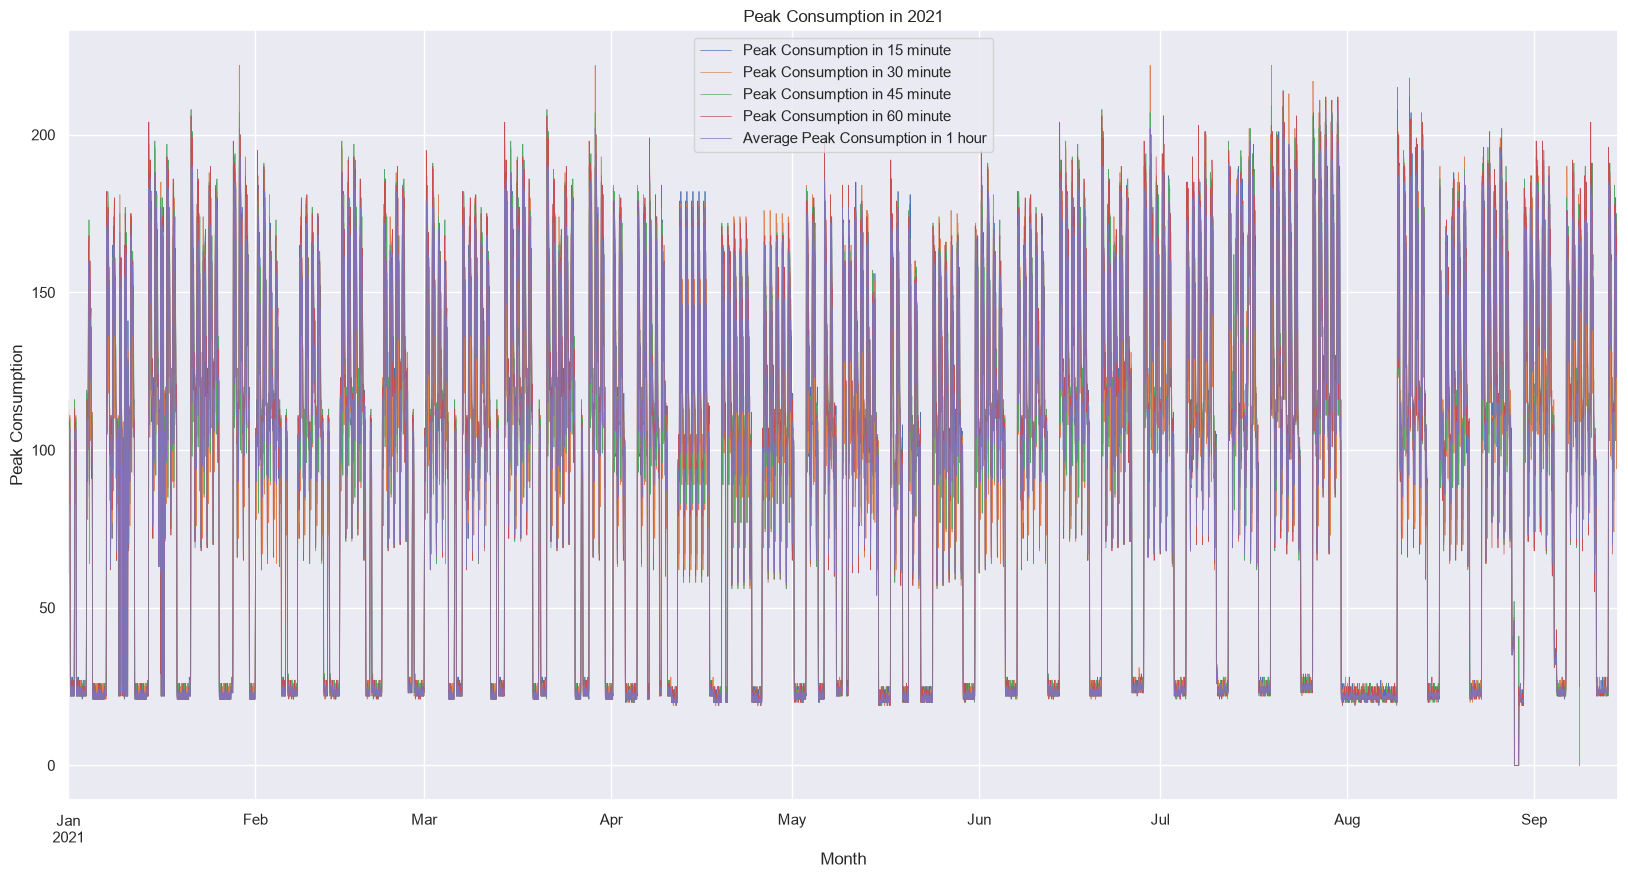

In [13]:
# 2021년도 최대수요전력 값 시각화
df.loc["2021"].plot(linewidth=0.5)

plt.title("Peak Consumption in 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

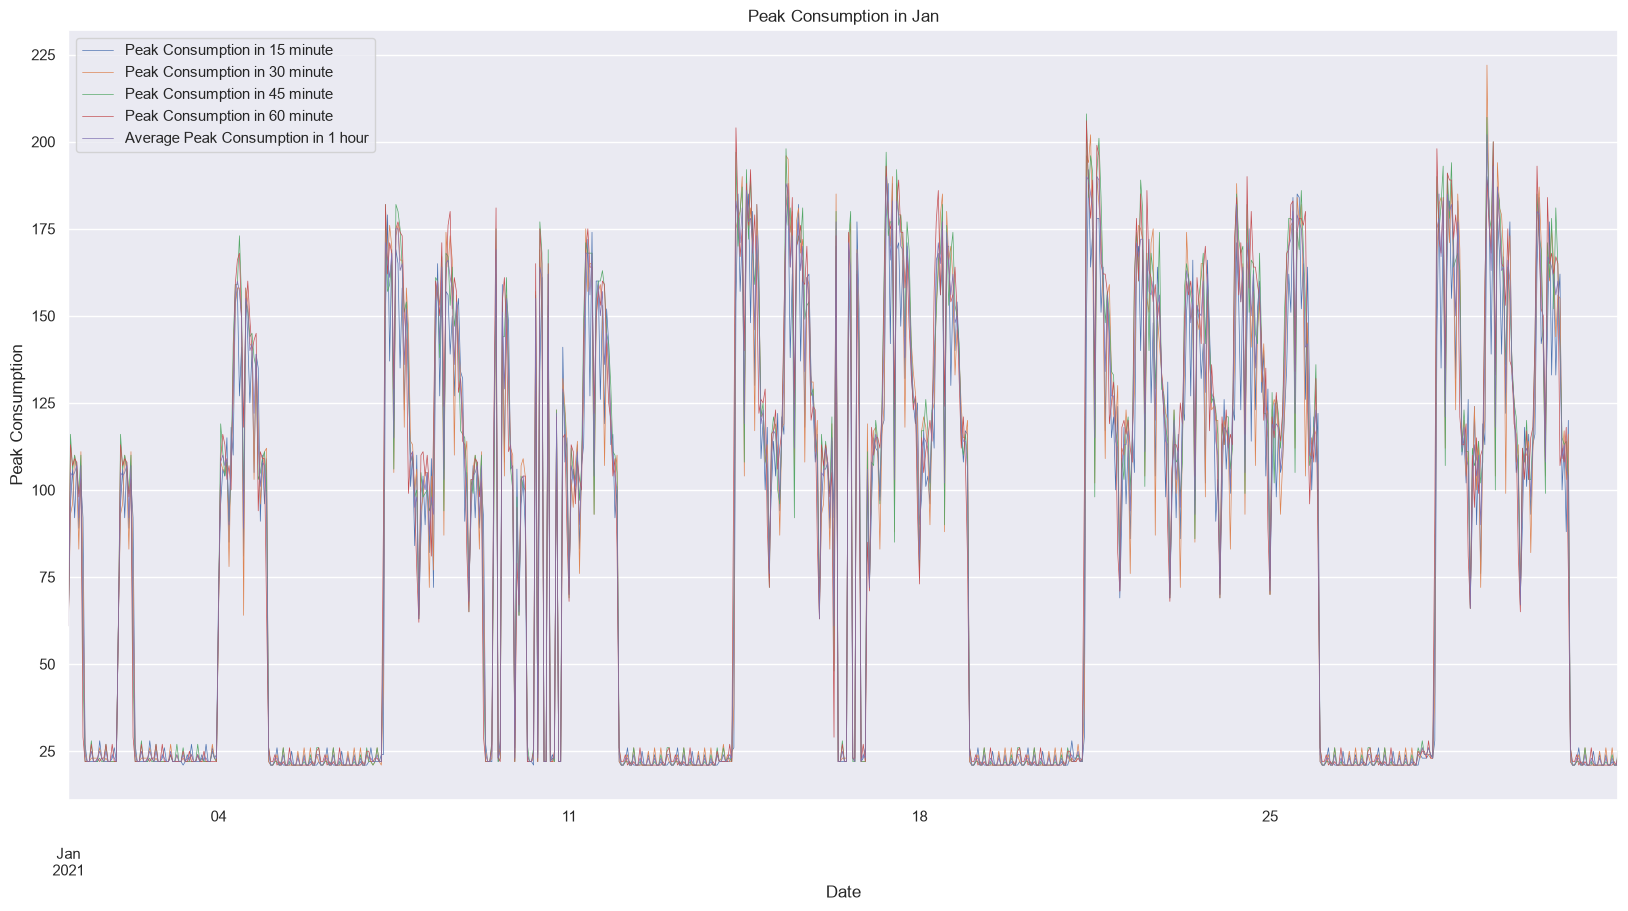

In [14]:
# 2021년도 1월 최대수요전력 값 시각화
df.loc["2021-01"].plot(linewidth = 0.5)

plt.title("Peak Consumption in Jan")
plt.ylabel("Peak Consumption")
plt.show()

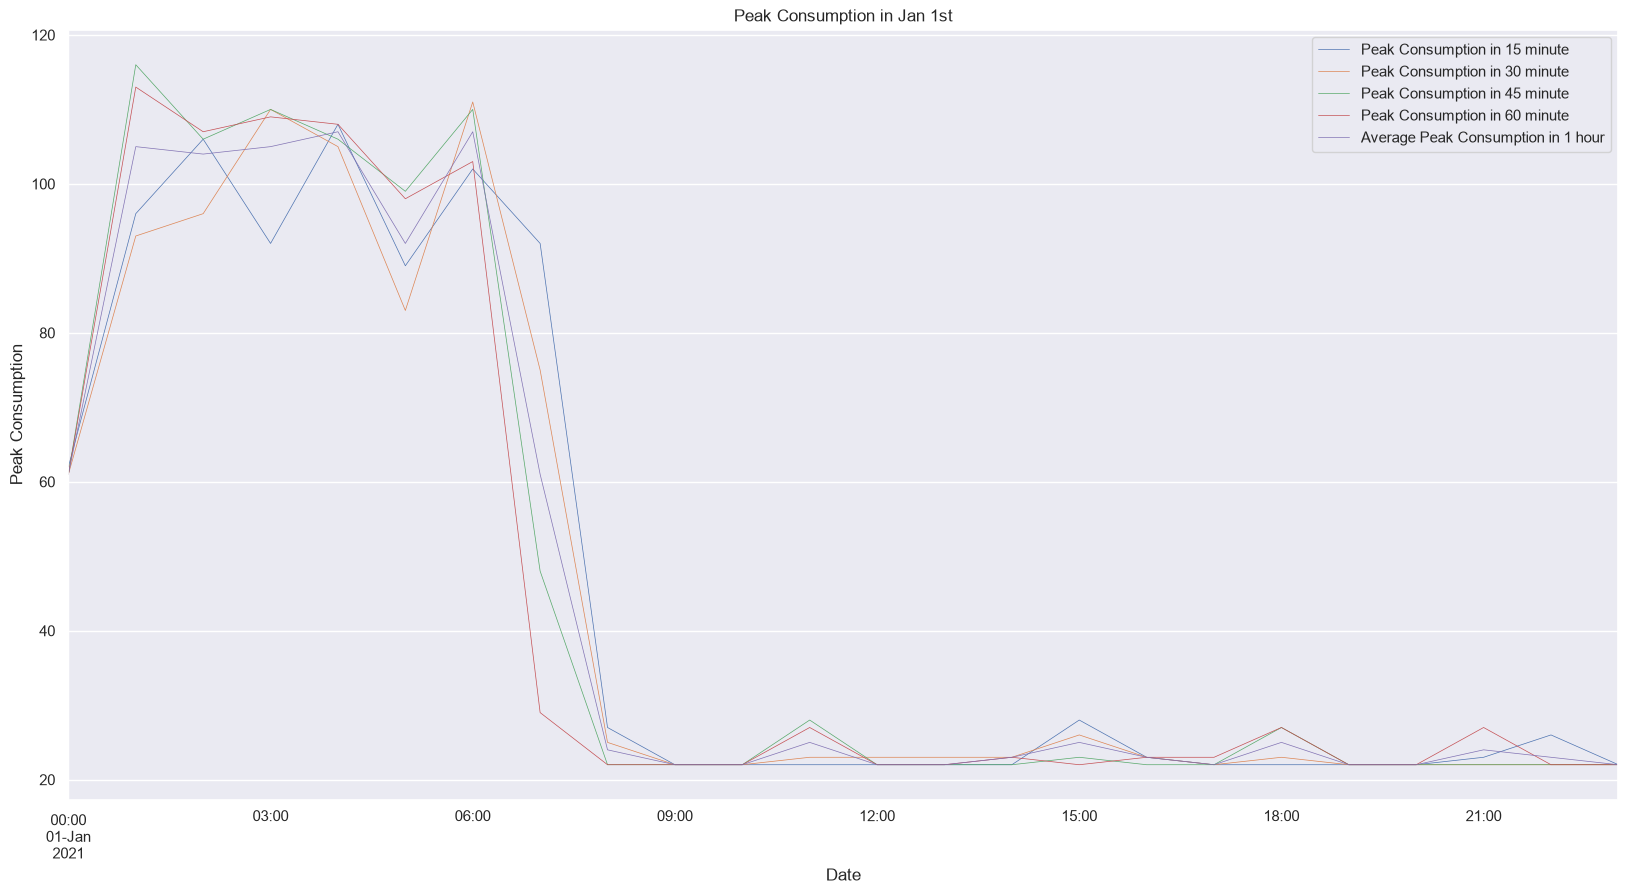

In [15]:
# 2021년도 1월 1일 최대수요전력 값 시각화
df.loc["2021-01-01"].plot(linewidth = 0.5)

plt.title("Peak Consumption in Jan 1st")
plt.ylabel("Peak Consumption")
plt.show()

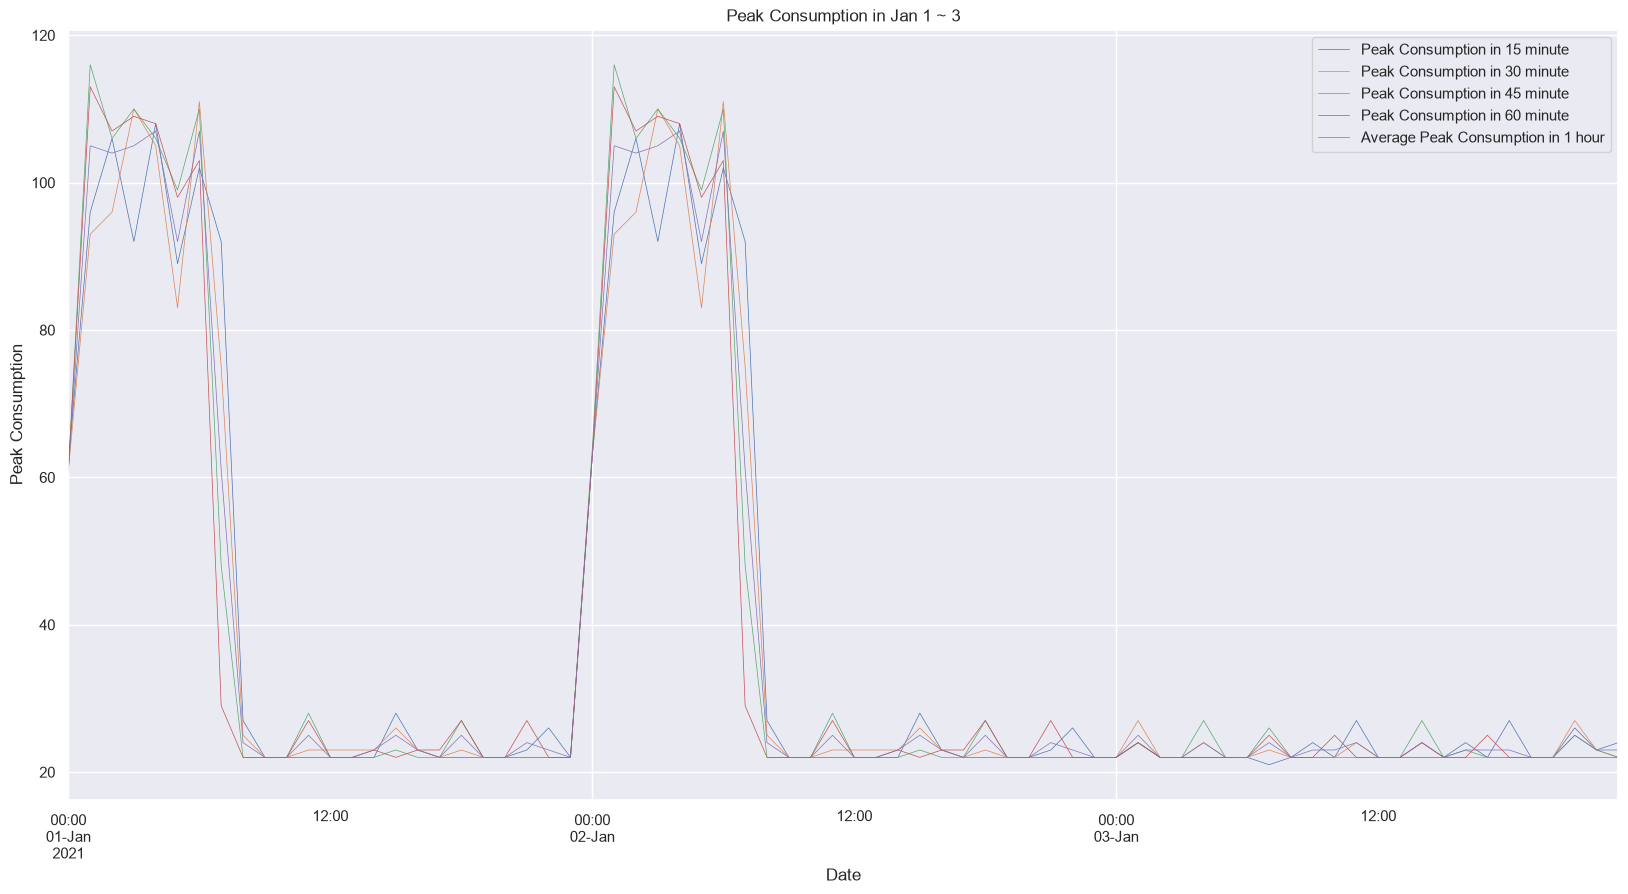

In [16]:
# 2021년도 1월 1일부터 3일까지의 최대수요전력 값 시각화
df.loc["2021-01":"2021-01-03"].plot(linewidth = 0.5)

plt.title("Peak Consumption in Jan 1 ~ 3")
plt.ylabel("Peak Consumption")
plt.show()

#### 3-5. 주말 및 공휴일 데이터 구분

In [17]:
df["Vacation"] = np.zeros(len(df))
df["Weekend"] = np.zeros(len(df))
df.head()

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61,0.0,0.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105,0.0,0.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104,0.0,0.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105,0.0,0.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107,0.0,0.0


In [18]:
# dayofweek를 활용한 요일 값 확인하기
df.loc["2021-01-01"].index.dayofweek

Index([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype='int32', name='Date')

In [19]:
df.loc[
    (df.index.dayofweek == 5) | (df.index.dayofweek == 6),
    "Weekend"
] = 1

df

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61,0.0,0.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105,0.0,0.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104,0.0,0.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105,0.0,0.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107,0.0,0.0
...,...,...,...,...,...,...,...
2021-09-14 19:00:00,152.0,151.0,171.0,139.0,153,0.0,0.0
2021-09-14 20:00:00,124.0,130.0,128.0,130.0,128,0.0,0.0
2021-09-14 21:00:00,134.0,130.0,125.0,124.0,128,0.0,0.0


In [20]:
# 공휴일 변수 선언하기
holidays = ["2021-01-01", "2021-02-11", "2021-02-12","2021-03-01", "2021-05-05", "2021-05-19", "2021-08-16"]

In [21]:
# 반복문 활용해서 값 부여하기
for gun,j in df.iterrows():
    if str(gun)[:10] in holidays:
        df.loc[gun, "Vacation"] =1

df.head(5)

,Peak Consumption in 15 minute,Peak Consumption in 30 minute,Peak Consumption in 45 minute,Peak Consumption in 60 minute,Average Peak Consumption in 1 hour,Vacation,Weekend
Date,,,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,61,1.0,0.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,105,1.0,0.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,104,1.0,0.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,105,1.0,0.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,107,1.0,0.0


In [22]:
# csv 파일 저장하기
df.to_csv("../results/daily_data_seasonality.csv", index=True)

#### 3-6. Window Features 생성
- window란 : 시간 단위
- 일주일 24시간 이므로 7*24 = 168
- 각 시점 t에 대해 과거 168시간(t-1 ~ t-168) 값을 feature로 만들고, 과거 값이 없는 앞 168시간은 제거한다

In [23]:
# 파일 불러오기
daily_data = pd.read_csv(
    "../results/daily_data_seasonality.csv",
    header=0,
    index_col=0,
    parse_dates=True
)

In [24]:
daily_data =daily_data[["Peak Consumption in 15 minute"]]
daily_data

,Peak Consumption in 15 minute
Date,
2021-01-01 00:00:00,62.0
2021-01-01 01:00:00,96.0
2021-01-01 02:00:00,106.0
2021-01-01 03:00:00,92.0
2021-01-01 04:00:00,108.0
...,...
2021-09-14 19:00:00,152.0
2021-09-14 20:00:00,124.0
2021-09-14 21:00:00,134.0


In [25]:
n_times_advance = 1
n_times_windows =168

In [26]:
target_col = "Peak Consumption in 15 minute"
lag_steps = range(n_times_advance, n_times_advance + n_times_windows)
lag_cols = [f"{target_col}_t-{k}" for k in lag_steps]

# shift(k) = k시간 전 값. 컬럼을 한 번에 만들어 붙인다
lag_frame = pd.concat(
    {col: daily_data[target_col].shift(k) for col, k in zip(lag_cols, lag_steps)},
    axis=1,
)
daily_data = pd.concat([daily_data[[target_col]], lag_frame], axis=1)
daily_data

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,...,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,62.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 01:00:00,96.0,62.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 02:00:00,106.0,96.0,62.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 03:00:00,92.0,106.0,96.0,62.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-01 04:00:00,108.0,92.0,106.0,96.0,62.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-14 19:00:00,152.0,158.0,117.0,164.0,132.0,161.0,149.0,135.0,155.0,143.0,...,113.0,96.0,115.0,100.0,78.0,117.0,104.0,133.0,124.0,158.0
2021-09-14 20:00:00,124.0,152.0,158.0,117.0,164.0,132.0,161.0,149.0,135.0,155.0,...,89.0,113.0,96.0,115.0,100.0,78.0,117.0,104.0,133.0,124.0
2021-09-14 21:00:00,134.0,124.0,152.0,158.0,117.0,164.0,132.0,161.0,149.0,135.0,...,110.0,89.0,113.0,96.0,115.0,100.0,78.0,117.0,104.0,133.0


In [27]:
# 앞 168시간은 과거 1주일 값이 없으므로(NaN) 학습에서 제외한다
print("제거 전:", len(daily_data))
daily_data = daily_data.dropna()
print("제거 후:", len(daily_data), "| 시작 시각:", daily_data.index.min())

제거 전: 6168
제거 후: 6000 | 시작 시각: 2021-01-08 00:00:00


In [28]:
daily_data.to_csv("../results/daily_data_seasonality_168.csv", index = True)
daily_data.head(3)

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,...,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-08 00:00:00,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,158.0,135.0,...,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0,96.0,62.0
2021-01-08 01:00:00,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,158.0,...,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0,96.0
2021-01-08 02:00:00,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,...,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0


In [29]:
# 저장된 원본 시계열로 lag 값을 다시 계산해 일치하는지 확인
original_series = pd.read_csv(
    "../results/daily_data_seasonality.csv", index_col=0, parse_dates=True
)[target_col]

for j in range(1, 169):
    expected = original_series.shift(j).loc[daily_data.index]
    assert daily_data[f"{target_col}_t-{j}"].equals(expected), f"t-{j} 결과 불일치"

assert not daily_data.isna().any().any(), "결측 lag가 남아 있음"
print("모든 lag feature 결과 일치, 결측 lag 없음")

모든 lag feature 결과 일치, 결측 lag 없음


## 4. 훈련/검증/테스트 데이터 분리

In [30]:
# 패키지 불러오기
import math
from sklearn.model_selection import train_test_split


In [31]:
daily_data_168 = pd.read_csv('../results/daily_data_seasonality_168.csv',
                header=0, index_col=0, parse_dates=True)
daily_data_168.head()

,Peak Consumption in 15 minute,Peak Consumption in 15 minute_t-1,Peak Consumption in 15 minute_t-2,Peak Consumption in 15 minute_t-3,Peak Consumption in 15 minute_t-4,Peak Consumption in 15 minute_t-5,Peak Consumption in 15 minute_t-6,Peak Consumption in 15 minute_t-7,Peak Consumption in 15 minute_t-8,Peak Consumption in 15 minute_t-9,...,Peak Consumption in 15 minute_t-159,Peak Consumption in 15 minute_t-160,Peak Consumption in 15 minute_t-161,Peak Consumption in 15 minute_t-162,Peak Consumption in 15 minute_t-163,Peak Consumption in 15 minute_t-164,Peak Consumption in 15 minute_t-165,Peak Consumption in 15 minute_t-166,Peak Consumption in 15 minute_t-167,Peak Consumption in 15 minute_t-168
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-08 00:00:00,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,158.0,135.0,...,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0,96.0,62.0
2021-01-08 01:00:00,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,158.0,...,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0,96.0
2021-01-08 02:00:00,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,123.0,...,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0,106.0
2021-01-08 03:00:00,90.0,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,154.0,...,22.0,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0,92.0
2021-01-08 04:00:00,105.0,90.0,104.0,87.0,64.0,110.0,84.0,110.0,101.0,141.0,...,22.0,22.0,22.0,22.0,22.0,27.0,92.0,102.0,89.0,108.0


In [32]:
# 시간순 분할: 마지막 336시간(2021-09-01 ~ 09-14)은 test, 그 직전 336시간은 validation
TEST_HOURS = 336
VAL_HOURS = 336
length_train_168 = len(daily_data_168) - TEST_HOURS - VAL_HOURS

split_index = daily_data_168.index
print("Train     :", split_index[0], "~", split_index[length_train_168 - 1], f"({length_train_168})")
print("Validation:", split_index[length_train_168], "~", split_index[-TEST_HOURS - 1], f"({VAL_HOURS})")
print("Test      :", split_index[-TEST_HOURS], "~", split_index[-1], f"({TEST_HOURS})")

Train     : 2021-01-08 00:00:00 ~ 2021-08-17 23:00:00 (5328)
Validation: 2021-08-18 00:00:00 ~ 2021-08-31 23:00:00 (336)
Test      : 2021-09-01 00:00:00 ~ 2021-09-14 23:00:00 (336)


In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler_168 = MinMaxScaler(feature_range=(0,1))
scaler_168

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [34]:
# 스케일러는 train 구간으로만 fit 하고, validation/test는 transform만 한다
scaler_168.fit(daily_data_168.iloc[:length_train_168])
daily_data_sc_168 = scaler_168.transform(daily_data_168)

In [35]:
# 훈련 데이터 선언
data_train_168 = daily_data_sc_168[:length_train_168]

# 검증 데이터 선언 (early stopping 기준)
data_val_168 = daily_data_sc_168[length_train_168:-TEST_HOURS]

# 평가 데이터 선언
data_test_168 = daily_data_sc_168[-TEST_HOURS:]

In [36]:
data_train_Y_168 = data_train_168[:,0]
data_train_X_168 = data_train_168[:,1:]
data_val_Y_168 = data_val_168[:,0]
data_val_X_168 = data_val_168[:,1:]
data_test_Y_168 = data_test_168[:,0]
data_test_X_168 = data_test_168[:,1:]

In [37]:
# lag 컬럼 순서는 t-1, t-2, …, t-168 (최신 → 과거)
# 과거 → 최신 순으로 뒤집은 뒤 (7일, 24시간)으로 reshape 한다
#   timestep 0 = 7일 전 하루(t-168 ~ t-145), timestep 6 = 직전 24시간(t-24 ~ t-1)
def to_sequence(x):
    return x[:, ::-1].reshape(-1, 7, 24)

lag_order = to_sequence(np.array([lag_cols]))[0]
print("timestep 0:", lag_order[0][0].split("_")[-1], "~", lag_order[0][-1].split("_")[-1])
print("timestep 6:", lag_order[-1][0].split("_")[-1], "~", lag_order[-1][-1].split("_")[-1])

seq_train_X_168 = to_sequence(data_train_X_168)
seq_val_X_168 = to_sequence(data_val_X_168)
seq_test_X_168 = to_sequence(data_test_X_168)
print(seq_train_X_168.shape, seq_val_X_168.shape, seq_test_X_168.shape)

timestep 0: t-168 ~ t-145
timestep 6: t-24 ~ t-1
(5328, 7, 24) (336, 7, 24) (336, 7, 24)


## 5. 모델 구축 및 훈련

In [38]:
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Input, SimpleRNN
from keras.callbacks import EarlyStopping

# python / numpy / tensorflow 시드를 고정하고 연산을 결정적으로 만들어 재실행 결과를 동일하게 한다
keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [39]:
model_168 = Sequential([
    Input(shape=(7, 24)),
    SimpleRNN(50),
    Dense(1),
])
opt = tf.keras.optimizers.Adam(learning_rate = 0.0001)
model_168.compile(loss ='mean_squared_error', optimizer = opt)

# validation loss가 30 epoch 동안 개선되지 않으면 멈추고, 가장 좋았던 가중치로 되돌린다
early_stopping = EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)
history_168 = model_168.fit(
    seq_train_X_168, data_train_Y_168,
    validation_data=(seq_val_X_168, data_val_Y_168),
    epochs=500,
    callbacks=[early_stopping],
    verbose=0,
)

best_epoch = int(np.argmin(history_168.history["val_loss"])) + 1
print(f"학습 epoch: {len(history_168.history['loss'])}, best epoch: {best_epoch}, "
      f"best val_loss: {min(history_168.history['val_loss']):.5f}")
model_168.summary()

E0000 00:00:1790660264.675309 29808712 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


학습 epoch: 249, best epoch: 219, best val_loss: 0.00296


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         3,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,405 (44.55 KB)

 Trainable params: 3,801 (14.85 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,604 (29.71 KB)

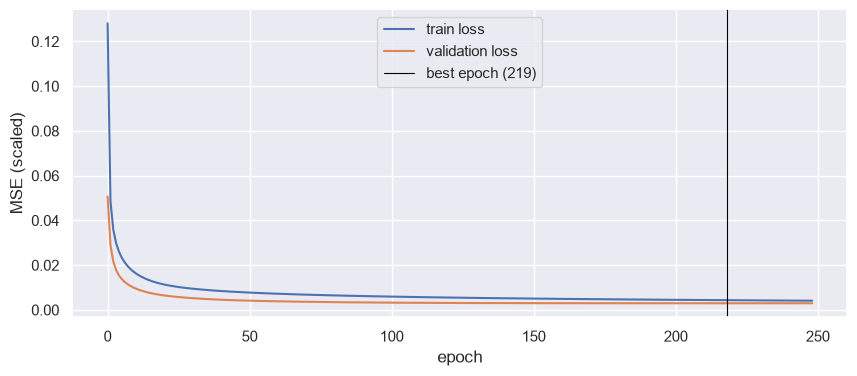

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(history_168.history["loss"], label="train loss")
plt.plot(history_168.history["val_loss"], label="validation loss")
plt.axvline(best_epoch - 1, color="black", linewidth=0.8, label=f"best epoch ({best_epoch})")
plt.xlabel("epoch")
plt.ylabel("MSE (scaled)")
plt.legend()
plt.show()

In [41]:
preds_168 = model_168.predict(seq_test_X_168, verbose=0)

E0000 00:00:1790660291.620969 29808712 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [42]:
data_predicted_168= np.concatenate((preds_168, data_test_X_168), axis=1)
data_predicted_168

array([[0.17538238, 0.44680851, 0.4787234 , ..., 0.5106383 , 0.37765957,
        0.32978723],
       [0.35335979, 0.34042553, 0.44680851, ..., 0.37765957, 0.5106383 ,
        0.37765957],
       [0.44197017, 0.42021277, 0.34042553, ..., 0.4787234 , 0.37765957,
        0.5106383 ],
       ...,
       [0.58911431, 0.55851064, 0.70744681, ..., 0.5212766 , 0.45212766,
        0.60638298],
       [0.47700897, 0.61170213, 0.55851064, ..., 0.31382979, 0.5212766 ,
        0.45212766],
       [0.51567554, 0.43085106, 0.61170213, ..., 0.43085106, 0.31382979,
        0.5212766 ]], shape=(336, 169))

In [43]:
data_predicted_168=scaler_168.inverse_transform(data_predicted_168)
data_predicted_168

array([[ 51.97188663, 103.        , 109.        , ..., 115.        ,
         90.        ,  81.        ],
       [ 85.43164027,  83.        , 103.        , ...,  90.        ,
        115.        ,  90.        ],
       [102.09039187,  98.        ,  83.        , ..., 109.        ,
         90.        , 115.        ],
       ...,
       [129.75348997, 124.        , 152.        , ..., 117.        ,
        104.        , 133.        ],
       [108.6776861 , 134.        , 124.        , ...,  78.        ,
        117.        , 104.        ],
       [115.94700241, 100.        , 134.        , ..., 100.        ,
         78.        , 117.        ]], shape=(336, 169))

In [44]:
# test 구간 시각은 데이터 index에서 그대로 가져온다
index_column = daily_data_168.index[-TEST_HOURS:]
best_pred_168 = pd.DataFrame(data=data_predicted_168[:,0], index=index_column)
best_pred_168 = best_pred_168.rename(columns={0: "forecasting"})
best_pred_168.to_csv("../results/the_best_rnn_pred_168.csv",index =True)

## 6. 분석 시각화

In [45]:
data_original = daily_data[["Peak Consumption in 15 minute"]]

In [46]:
forecast = pd.read_csv("../results/the_best_rnn_pred_168.csv")["forecasting"]
forecast

0       51.971887
1       85.431640
2      102.090392
3       95.584322
4      107.258062
          ...    
331    161.077919
332    116.639950
333    129.753490
334    108.677686
335    115.947002
Name: forecasting, Length: 336, dtype: float64

In [47]:
compare_result = pd.DataFrame(np.array(data_original['Peak Consumption in 15 minute'][-336:]),columns=['Original 15 minute'])

In [48]:
compare_result['forecasting'] = forecast
compare_result

,Original 15 minute,forecasting
0,83.0,51.971887
1,98.0,85.431640
2,121.0,102.090392
3,90.0,95.584322
4,114.0,107.258062
...,...,...
331,152.0,161.077919
332,124.0,116.639950
333,134.0,129.753490
334,100.0,108.677686


In [49]:
index_column = pd.date_range(start ='2021-09-01 00:00', end ='2021-09-14 23:00', freq ='h')
index_column

DatetimeIndex(['2021-09-01 00:00:00', '2021-09-01 01:00:00',
               '2021-09-01 02:00:00', '2021-09-01 03:00:00',
               '2021-09-01 04:00:00', '2021-09-01 05:00:00',
               '2021-09-01 06:00:00', '2021-09-01 07:00:00',
               '2021-09-01 08:00:00', '2021-09-01 09:00:00',
               ...
               '2021-09-14 14:00:00', '2021-09-14 15:00:00',
               '2021-09-14 16:00:00', '2021-09-14 17:00:00',
               '2021-09-14 18:00:00', '2021-09-14 19:00:00',
               '2021-09-14 20:00:00', '2021-09-14 21:00:00',
               '2021-09-14 22:00:00', '2021-09-14 23:00:00'],
              dtype='datetime64[us]', length=336, freq='h')

In [50]:
compare_result.index = index_column
compare_result.index.names = ["Date"]
compare_result.head()

,Original 15 minute,forecasting
Date,,
2021-09-01 00:00:00,83.0,51.971887
2021-09-01 01:00:00,98.0,85.431640
2021-09-01 02:00:00,121.0,102.090392
2021-09-01 03:00:00,90.0,95.584322
2021-09-01 04:00:00,114.0,107.258062


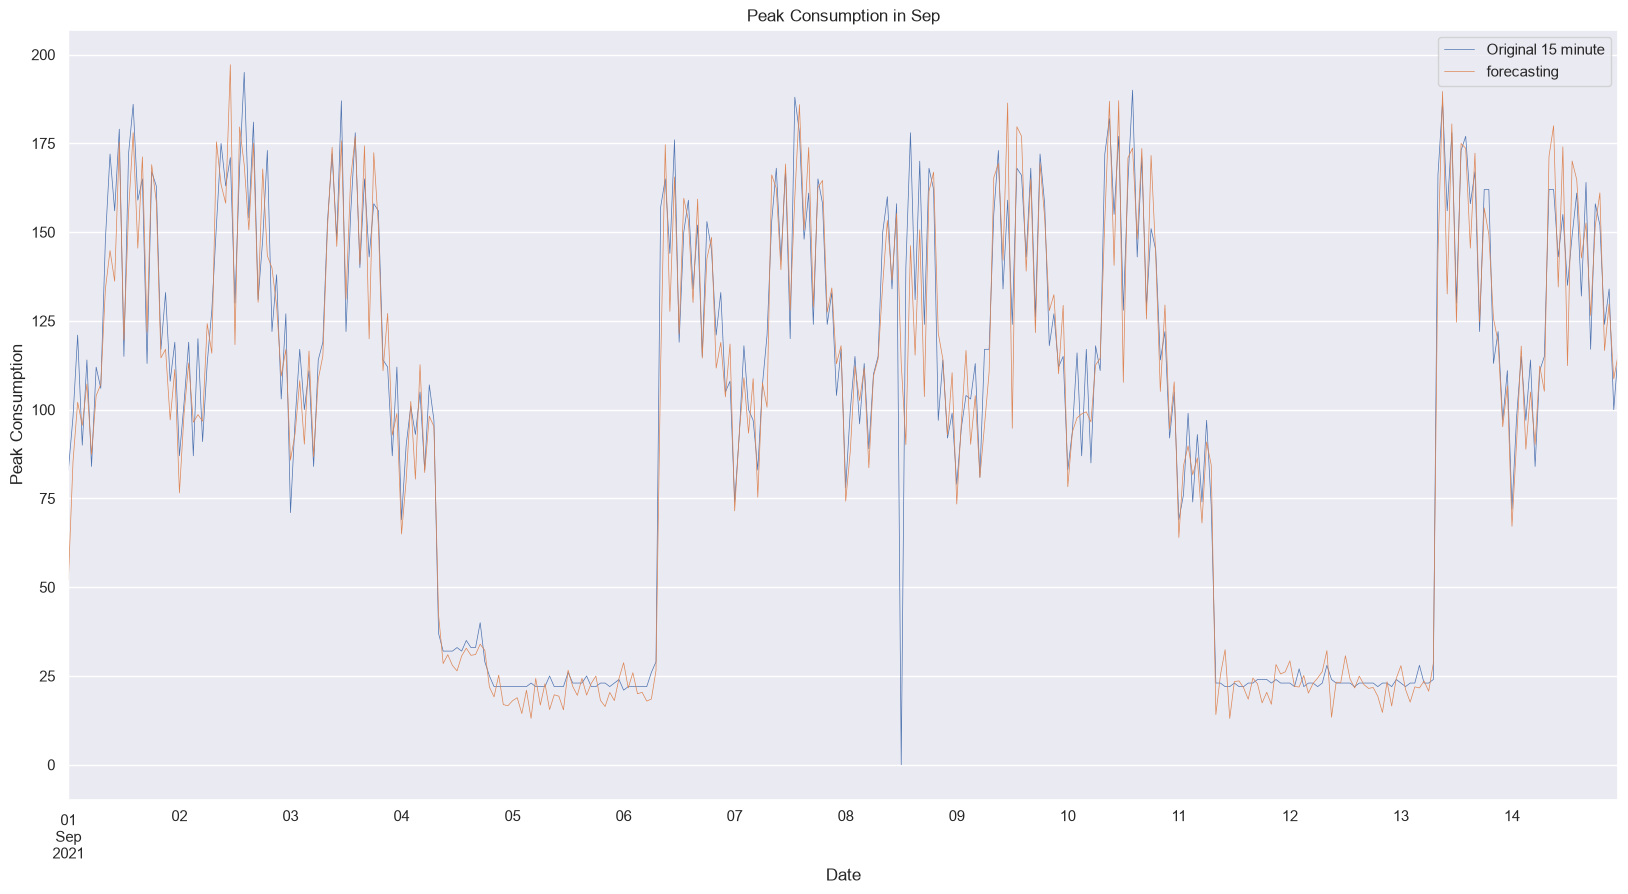

In [51]:
compare_result.loc["2021-09"].plot(linewidth =0.5)
plt.title("Peak Consumption in Sep")
plt.ylabel("Peak Consumption")
plt.show()

#### 기준선 비교
test 구간(2021-09-01 ~ 09-14)의 각 시점마다 **실제 관측된 과거 168시간**을 입력으로 넣어 **1시간 뒤**를 예측한 결과다.
(168시간을 한꺼번에 예측한 것이 아니다.)
단순 규칙보다 오차가 작아야 의미 있는 학습을 한 것이다.

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

actual = compare_result["Original 15 minute"]
candidates = {
    "SimpleRNN": compare_result["forecasting"],
    "1시간 전 값 (lag_1)": daily_data.loc[compare_result.index, f"{target_col}_t-1"],
    "1일 전 같은 시각 (lag_24)": daily_data.loc[compare_result.index, f"{target_col}_t-24"],
    "1주 전 같은 시각 (lag_168)": daily_data.loc[compare_result.index, f"{target_col}_t-168"],
}

pd.DataFrame(
    {
        "MAE": {name: mean_absolute_error(actual, pred) for name, pred in candidates.items()},
        "MSE": {name: mean_squared_error(actual, pred) for name, pred in candidates.items()},
        "RMSE": {name: root_mean_squared_error(actual, pred) for name, pred in candidates.items()},
    }
).round(3)

,MAE,MSE,RMSE
SimpleRNN,7.872,146.051,12.085
1시간 전 값 (lag_1),19.988,844.298,29.057
1일 전 같은 시각 (lag_24),36.283,3541.295,59.509
1주 전 같은 시각 (lag_168),9.190,172.702,13.142


#### 결과 해석 (seed 42 기준)
- SimpleRNN의 test 오차는 MAE 7.87, RMSE 12.09다. 가장 강한 단순 규칙인 "1주 전 같은 시각"(MAE 9.19, RMSE 13.14)보다 MAE가 약 14% 낮다.
- 이 데이터에서는 1주 전 값이 1시간 전·1일 전 값보다 훨씬 좋은 예측값이다. 공장이 주 단위로 가동하기 때문이다.
- early stopping은 validation(2021-08-18 ~ 08-31) 기준 219 epoch에서 가장 좋은 가중치를 골랐다. test 구간은 모델 선택에 사용하지 않았다.
- 이전 버전의 MAE 7.41은 seed를 고정하지 않고 여러 번 재실행한 결과 중 test에서 좋은 것을 고른 값이라 직접 비교할 수 없다.